# Signal Processing Pipeline: WESAD Dataset

## Project Overview

The WESAD (Wearable Stress and Affect Detection) dataset contains physiological
data recorded from 15 subjects undergoing three experimentally induced affective
states: baseline, stress, and amusement. Subjects also completed two guided
meditation periods between conditions.

This notebook implements the full signal processing pipeline for stress prediction
using only signals from the wrist-worn Empatica E4 device. Using wrist-only data
makes the approach more practical for real-world deployment on consumer
smartwatches, which are far more common than chest-worn medical devices.
This is also a mandatory requirement of the project specification.

## Pipeline Structure

1. **Data Loading** — Load raw `.pkl` files for all 15 subjects and inspect
   the data structure and experimental protocol
2. **Signal Preprocessing** — Apply signal-specific filters to BVP, EDA,
   TEMP, and ACC to remove noise while preserving physiologically relevant
   information
3. **Sliding Window Segmentation** — Segment preprocessed signals into
   60-second windows following Schmidt et al. (2018), Section 4.1
4. **Feature Extraction** — Extract statistical, time-domain, and
   frequency-domain features per window using NeuroKit2
5. **Save Features** — Export the feature matrix to CSV for use in the
   modelling notebook

## Key Design Decisions

| Decision | Choice | Source |
|----------|--------|--------|
| Device | Wrist only (Empatica E4) | Project specification |
| Labels kept | 1, 2, 3, 4 (baseline, stress, amusement, meditation) | Schmidt et al. (2018), Section 6 |
| Window size | 60 seconds | Schmidt et al. (2018), Section 4.1 |
| Window step | 0.25 seconds | Schmidt et al. (2018), Section 4.1 |
| Label assignment | Majority vote per window | Schmidt et al. (2018), Section 4.1 |
| BVP filter | Bandpass 0.5–8 Hz | Standard PPG processing practice |
| EDA filter | Lowpass 1 Hz | Adapted from paper's 5 Hz — see Section 2 |
| Feature extraction | NeuroKit2 | Project specification allows established libraries |

**Reference:** Schmidt et al. (2018), *Introducing WESAD, a Multimodal Dataset
for Wearable Stress and Affect Detection*, ICMI 2018.

## Section 0: Imports

We import all libraries needed for this notebook. The `helpers` module contains
custom functions for loading, filtering, segmenting, and extracting features
from the WESAD signals. `neurokit2` is used for physiological signal processing,
particularly for HRV feature extraction from BVP and tonic/phasic decomposition
of EDA.

In [1]:
import helpers as h
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk

## Section 1: Data Loading

The WESAD dataset stores each subject's data as a `.pkl` file containing raw
signals from both the chest (RespiBAN) and wrist (Empatica E4) devices, along
with a label array. We scan the data directory to locate all subject files
dynamically, avoiding hardcoding subject names.

Note: The dataset originally included 17 subjects but S1 and S12 were discarded
due to sensor malfunction during recording, leaving 15 usable subjects
(Schmidt et al., 2018, Section 3.1).

In [2]:
DATA_ROOT = "./WESAD"

pkl_files = sorted([
    os.path.join(root, f)
    for root, dirs, files in os.walk(DATA_ROOT)
    for f in files if f.endswith(".pkl")
])

print(f"Found {len(pkl_files)} subject files in {DATA_ROOT}")

subjects = [os.path.splitext(os.path.basename(p))[0] for p in pkl_files]
print("Subjects found:", subjects)

Found 15 subject files in ./WESAD
Subjects found: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


All 15 subject files were found successfully. The subject IDs confirm that S1
and S12 are absent from the dataset, consistent with Schmidt et al. (2018),
Section 3.1. The subjects are not numbered consecutively (S2–S17 with gaps)
which is expected. All 15 files will be processed in the subsequent steps.

### 1.1 Inspecting a Single Subject

Before processing all subjects, we load a single subject (S2) to inspect
the raw data structure. This confirms the available signal modalities,
their shapes and sampling rates, and the label system used in the dataset.
We focus exclusively on the wrist device signals (Empatica E4) since this
is more practical for real-world deployment on consumer smartwatches and
is required by the project specification. The chest device (RespiBAN) data
is present in the file but will not be used.

In [3]:
# using Path here for simplicity
DATA_ROOT = Path(DATA_ROOT)

# inspecting one subject: condition timeline first, then selection
PREVIEW_ID = "S2"
data_preview = h.load_subject_pickle(DATA_ROOT, PREVIEW_ID, verbose=False)

print("\n── Data structure preview for subject ──")
print("Top-level keys:", list(data_preview.keys()))
print("Subject ID:", data_preview["subject"])
print("Signal devices:", list(data_preview["signal"].keys()))

print("\n── Wrist signals (Empatica E4) ──")
for sig_name, sig_val in data_preview["signal"]["wrist"].items():
    print(f"  {sig_name:6s}: shape={sig_val.shape}, dtype={sig_val.dtype}")

labels = np.asarray(data_preview["label"])
print("\n── Labels ──")
print(f"  Shape:          {labels.shape}")
print(f"  Dtype:          {labels.dtype}")
print(f"  Unique values:  {np.unique(labels)}")
print("  Value counts:")
for v in np.unique(labels):
    print(f"    {int(v)}: {int(np.sum(labels == v))} samples")

/Users/louiedaans/Desktop/healthcare-project/helpers.py:28: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")



── Data structure preview for subject ──
Top-level keys: ['signal', 'label', 'subject']
Subject ID: S2
Signal devices: ['chest', 'wrist']

── Wrist signals (Empatica E4) ──
  ACC   : shape=(194528, 3), dtype=float64
  BVP   : shape=(389056, 1), dtype=float64
  EDA   : shape=(24316, 1), dtype=float64
  TEMP  : shape=(24316, 1), dtype=float64

── Labels ──
  Shape:          (4255300,)
  Dtype:          int32
  Unique values:  [0 1 2 3 4 6 7]
  Value counts:
    0: 2142701 samples
    1: 800800 samples
    2: 430500 samples
    3: 253400 samples
    4: 537599 samples
    6: 45500 samples
    7: 44800 samples


The output confirms the data structure described in Schmidt et al. (2018),
Section 3.2. Each `.pkl` file contains three top-level keys: `signal`,
`label`, and `subject`. The wrist device provides four signal modalities:

- `BVP`: shape (389056, 1) at 64 Hz — Blood Volume Pulse
- `EDA`: shape (24316, 1) at 4 Hz — Electrodermal Activity
- `TEMP`: shape (24316, 1) at 4 Hz — Skin Temperature
- `ACC`: shape (194528, 3) at 32 Hz — 3-axis Accelerometer

The label array has shape (4255300,) confirming it is stored at 700 Hz
(the RespiBAN synchronization rate), significantly higher than any wrist
signal rate. Labels will therefore need to be downsampled to align with
each signal.

The label array contains 7 unique values. For our pipeline we keep four
conditions of interest:
- **Label 1** — Baseline (~19 min): neutral resting state
- **Label 2** — Stress (~10 min): Trier Social Stress Test (TSST)
- **Label 3** — Amusement (~6 min): funny video clips
- **Label 4** — Meditation (~13 min): guided breathing exercise

Labels 0, 5, 6, and 7 correspond to undefined periods and brief
transitions between conditions. These are discarded as they do not
represent stable affective states. Including meditation as a fourth
class is motivated by Schmidt et al. (2018), Section 6, which explicitly
suggests it as a direction for future work: *"the meditation period could
be added as an additional class, posing a four-class classification
problem."*

### 1.2 Verifying Sampling Frequencies

The paper (Schmidt et al., 2018, Section 3.2) specifies the sampling
frequencies for each Empatica E4 signal. We verify these empirically
by using the known label rate (700 Hz) to compute the total recording
duration, then back-calculating each signal's sampling frequency from
its number of samples. This confirms the data is structured exactly
as the paper describes before we proceed with any processing.

In [4]:
# hz of label (should be 700 according to WESAD paper)
FS_LABEL = 700

# still same subject
n_label_samples = len(labels)
recording_duration_s = n_label_samples / FS_LABEL
print(f"\nTotal recording duration: {recording_duration_s:.1f} s ({recording_duration_s/60:.1f} min)")

print("── Derived sampling frequencies (wrist) ──")
for sig_name, sig_val in data_preview["signal"]["wrist"].items():
    n_samples = sig_val.shape[0]
    fs_derived = n_samples / recording_duration_s
    print(f"  {sig_name:6s}: {n_samples:>8} samples -> {fs_derived:.1f} Hz")
print(f"  {'LABEL':6s}: {n_label_samples:>8} samples -> {FS_LABEL:.1f} Hz")


Total recording duration: 6079.0 s (101.3 min)
── Derived sampling frequencies (wrist) ──
  ACC   :   194528 samples -> 32.0 Hz
  BVP   :   389056 samples -> 64.0 Hz
  EDA   :    24316 samples -> 4.0 Hz
  TEMP  :    24316 samples -> 4.0 Hz
  LABEL :  4255300 samples -> 700.0 Hz


All derived sampling frequencies match exactly the values reported in
Schmidt et al. (2018), Section 3.2 — BVP: 64 Hz, EDA: 4 Hz, TEMP: 4 Hz,
ACC: 32 Hz, labels: 700 Hz. The total recording duration for S2 is
101.3 minutes, slightly longer than the ~91 minutes observed for S10
in the initial exploration, consistent with the inter-subject variability
in recording duration noted in the dataset. The large mismatch between
label rate (700 Hz) and signal rates means label indices must be converted
to each signal's own rate during windowing in Section 3.

### 1.3 Label Distribution and Condition Timeline

We map each label value to its condition name, compute the time spent
in each condition, and visualize the protocol timeline for subject S2.
This confirms the study protocol was followed correctly and gives us
a clear picture of how much usable data is available per condition
before we commit to any segmentation decisions.


Subject: S2
Label  Condition         Samples   Duration (s)   Duration (min)
----------------------------------------------------------------
  0    Not defined       2142701         3061.0             51.0
  1    Baseline           800800         1144.0             19.1
  2    Stress             430500          615.0             10.2
  3    Amusement          253400          362.0              6.0
  4    Meditation         537599          768.0             12.8
  6    Ignore              45500           65.0              1.1
  7    Ignore              44800           64.0              1.1


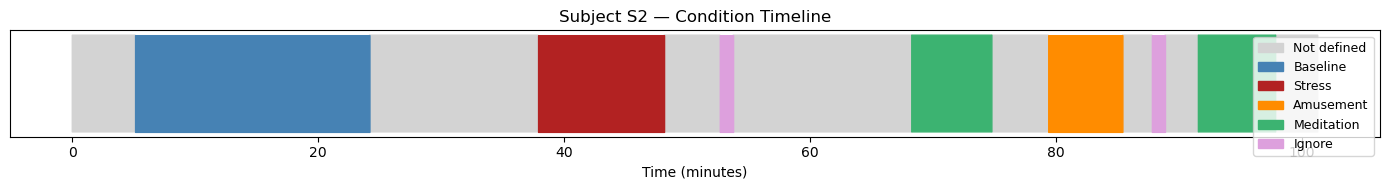

In [5]:
label_names = {
    0: "Not defined",
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation",
    5: "Ignore",
    6: "Ignore",
    7: "Ignore",
}

print(f"\nSubject: {data_preview['subject']}")
print(f"{'Label':<6} {'Condition':<14} {'Samples':>10} {'Duration (s)':>14} {'Duration (min)':>16}")
print("-" * 64)
for v in np.unique(labels):
    n = int(np.sum(labels == v))
    dur_s = n / FS_LABEL
    dur_min = dur_s / 60
    name = label_names.get(int(v), "Unknown")
    print(f"  {int(v):<4} {name:<14} {n:>10} {dur_s:>14.1f} {dur_min:>16.1f}")

# Condition timeline
time_axis = np.arange(len(labels)) / FS_LABEL / 60
colors = {
    0: "lightgrey",
    1: "steelblue",
    2: "firebrick",
    3: "darkorange",
    4: "mediumseagreen",
    5: "plum",
    6: "plum",
    7: "plum",
}

fig, ax = plt.subplots(figsize=(14, 2))
for v in np.unique(labels):
    mask = labels == v
    ax.fill_between(
        time_axis,
        0,
        1,
        where=mask,
        color=colors.get(int(v), "lightgrey"),
        label=label_names.get(int(v), "Unknown"),
    )

ax.set_xlabel("Time (minutes)")
ax.set_yticks([])
ax.set_title(f"Subject {data_preview['subject']} — Condition Timeline")

# Deduplicate legend entries
handles, lbls = ax.get_legend_handles_labels()
seen = {}
for hnd, lbl in zip(handles, lbls):
    if lbl not in seen:
        seen[lbl] = hnd
ax.legend(seen.values(), seen.keys(), loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

Subject S2 followed Version B of the protocol (Schmidt et al., 2018,
Figure 2) — baseline first, then stress, then amusement, each separated
by a meditation period. The four conditions we keep account for ~48
minutes of usable data (baseline: ~19 min, stress: ~10 min, amusement:
~6 min, meditation: ~13 min). The remaining ~53 minutes are discarded
(label 0: undefined periods, labels 6 and 7: brief transitions).

We keep labels 1, 2, 3, and 4 (baseline, stress, amusement, meditation).
Labels 0, 6, and 7 are discarded as they do not represent stable
affective states. Including meditation as a fourth class extends beyond
the paper's three-class benchmark and is directly motivated by Schmidt
et al. (2018), Section 6, which explicitly suggests it as a direction
for future work.

The clear class imbalance — baseline has roughly 3x more data than
amusement — is a structural property of the protocol consistent across
all subjects. This motivates using macro F1-score as the primary
evaluation metric rather than accuracy, as done in Schmidt et al.
(2018), Section 4.3.

In [6]:
# we keep labels 1, 2, 3, 4 (Baseline/Stress/Amusement/Meditation)
KEEP_LABELS = {1, 2, 3, 4}
print("\nKeeping labels:", KEEP_LABELS, "-> Baseline, Stress, Amusement, Meditation")


Keeping labels: {1, 2, 3, 4} -> Baseline, Stress, Amusement, Meditation


### 1.4 Dataset Overview Across All Subjects

Having inspected a single subject, we now load all 15 subjects and build
a compact summary to verify that the protocol was followed consistently
and that the class imbalance observed for S2 is a structural property
of the dataset rather than specific to one subject.


Compact summary table:


,subject,duration_s,BVP_n,EDA_n,TEMP_n,ACC_n,Baseline%,Stress%,Amusement%,Meditation%
0,S2,6079.0,389056,24316,24316,194528,39.598497,21.287653,12.530293,26.583557
1,S3,6493.0,415552,25972,25972,207776,38.841548,21.805782,12.776825,26.575845
2,S4,6423.0,411072,25692,25692,205536,38.989928,21.380461,12.525247,27.104364
3,S5,6258.0,400512,25032,25032,200256,39.787446,21.421455,12.421123,26.369977
4,S6,7071.0,452544,28284,28284,226272,39.478086,21.746403,12.445634,26.329876
5,S7,5238.0,335232,20952,20952,167616,39.692064,21.418989,12.449835,26.439112
6,S8,5466.0,349824,21864,21864,174912,38.901849,22.296184,12.312770,26.489197
7,S9,5223.0,334272,20892,20892,167136,39.464883,21.571906,12.441472,26.521739
8,S10,5496.0,351744,21984,21984,175872,38.398959,23.592581,12.105434,25.903026
9,S11,5233.0,334912,20932,20932,167456,39.085772,22.524004,12.189461,26.200764


Plotting label proportions by subject...


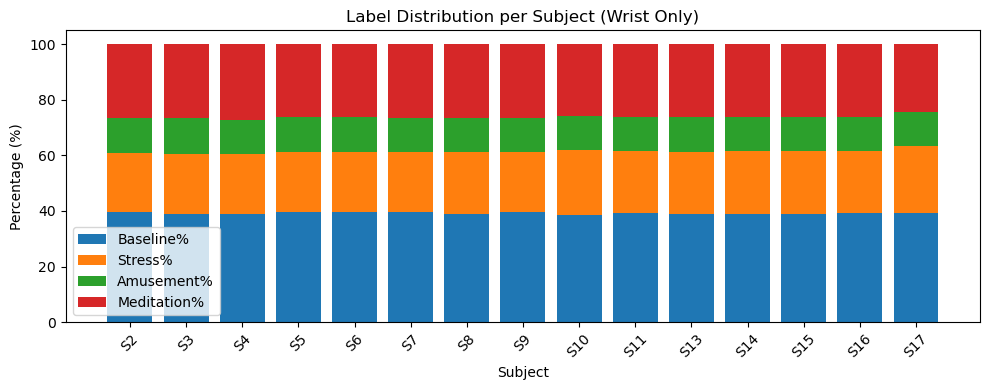

In [7]:
# loading all subjects and building a compact summary for better overview of the dataset

all_subjects_data = {}
# group data summaries
for subject_id in subjects:
    data = h.load_subject_pickle(DATA_ROOT, subject_id, verbose=False)
    all_subjects_data[subject_id] = data

rows = []
# build compact summary rows for each subject
for subject_id in sorted(all_subjects_data.keys(), key=lambda s: int(s[1:])):
    row = h.compact_summary(subject_id, all_subjects_data[subject_id])
    rows.append(row)
    
df_summary = pd.DataFrame(rows)
print("\nCompact summary table:")
display(df_summary)

# visualisation, stacked label proportions per subject
print("Plotting label proportions by subject...")
plt.figure(figsize=(10, 4))
bottom = np.zeros(len(df_summary))
for label in ["Baseline%", "Stress%", "Amusement%", "Meditation%"]:
    plt.bar(df_summary["subject"], df_summary[label], bottom=bottom, label=label)
    bottom += df_summary[label].values

plt.title("Label Distribution per Subject (Wrist Only)")
plt.ylabel("Percentage (%)")
plt.xlabel("Subject")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The summary table and stacked bar chart confirm that the label distribution
is remarkably consistent across all 15 subjects. Baseline accounts for
approximately 39% of each recording, stress ~22%, amusement ~12%, and
meditation ~26%. This consistency confirms that the class imbalance is a
structural property of the study protocol rather than a subject-specific
anomaly — every subject followed the same protocol durations regardless
of which version (A or B) they were assigned.

Total recording durations vary between ~87 minutes (S7) and ~118 minutes
(S6), reflecting differences in undefined periods between conditions
rather than differences in the conditions themselves. The usable condition
data is highly consistent across subjects as confirmed by the stable
percentages in the table.

This consistent class imbalance — particularly the underrepresentation
of amusement (~12%) relative to baseline (~39%) — means accuracy would
be a misleading metric since a naive classifier could score ~39% by
always predicting baseline. Macro F1-score is therefore used as the
primary evaluation metric throughout, consistent with Schmidt et al.
(2018), Section 4.3.

### 1.5 Raw Signal Visualization

Before applying any preprocessing, we visualize 60 seconds of each raw
wrist signal across the three main affective conditions (baseline, stress,
amusement) to build intuition about the data and confirm that
physiologically expected differences are visible even in the raw signals.
We also separately compare the two meditation segments — one following
amusement and one following stress — since these occur in different
physiological contexts and may look different from each other.


Visualising Raw Signals
Preview subject: S2

Visualising Raw Signals
Window length: 60s per condition
Conditions: {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}


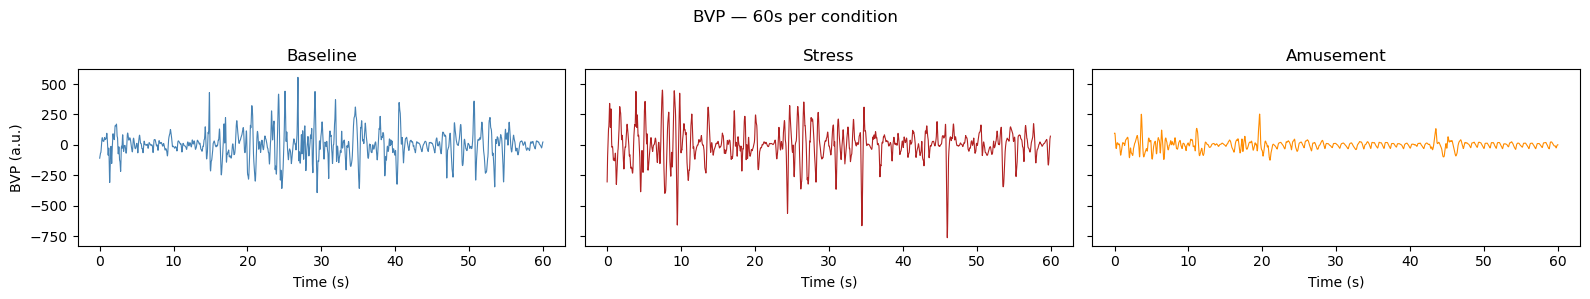

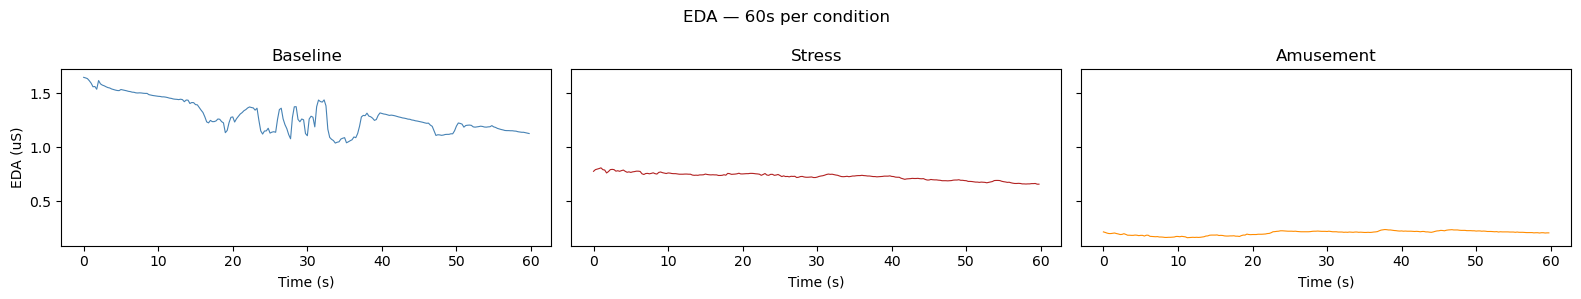

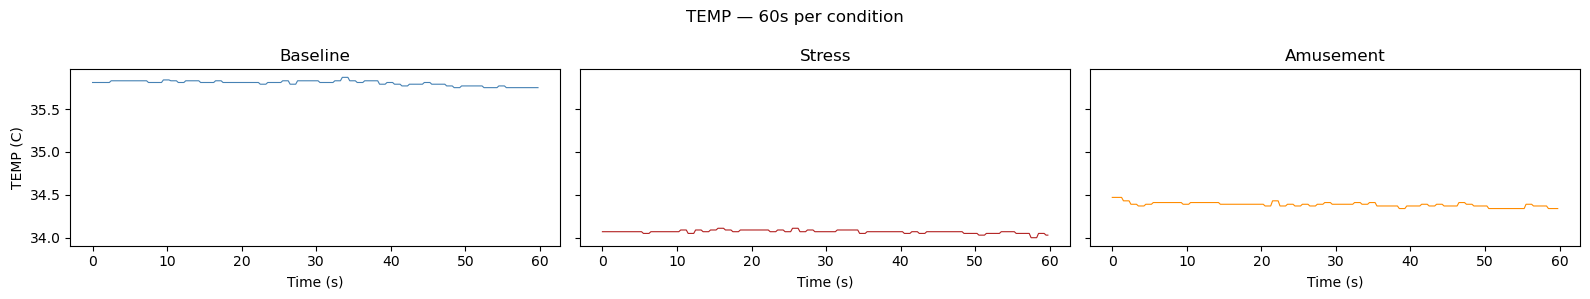

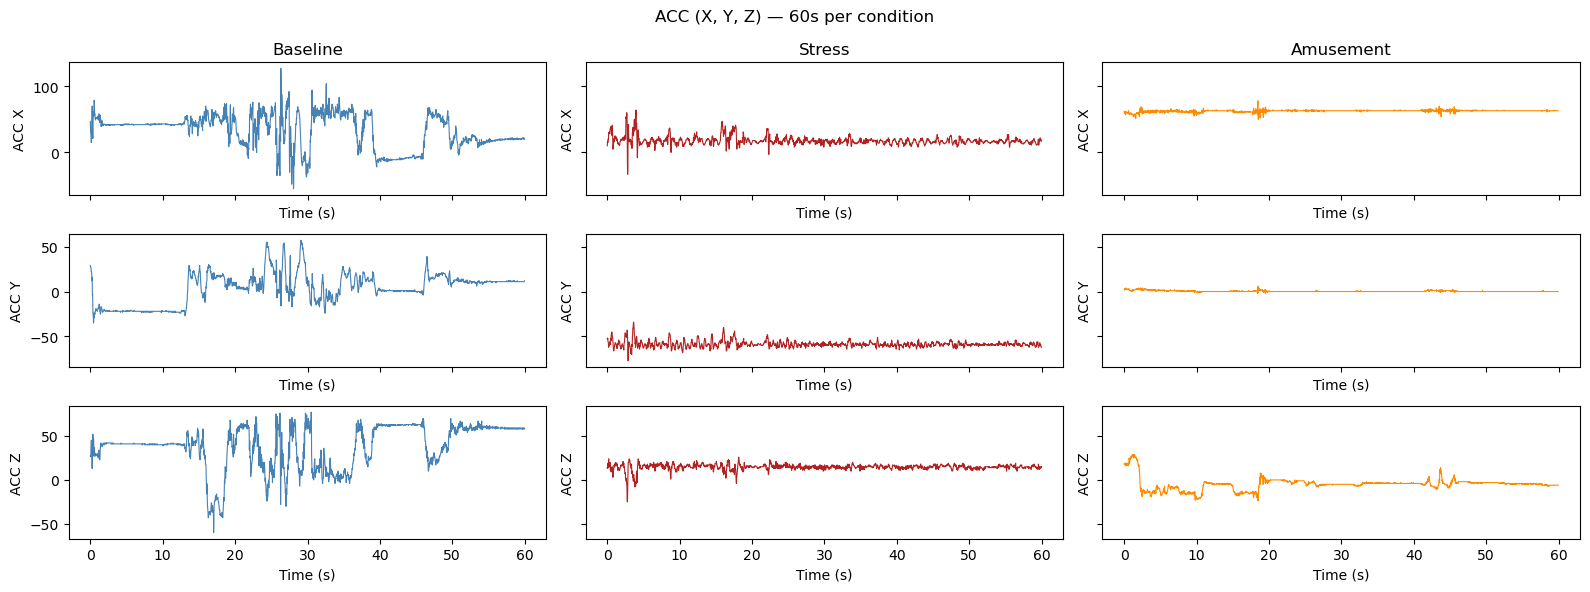


Meditation segments: start-of-block comparison
Meditation segments found: 2


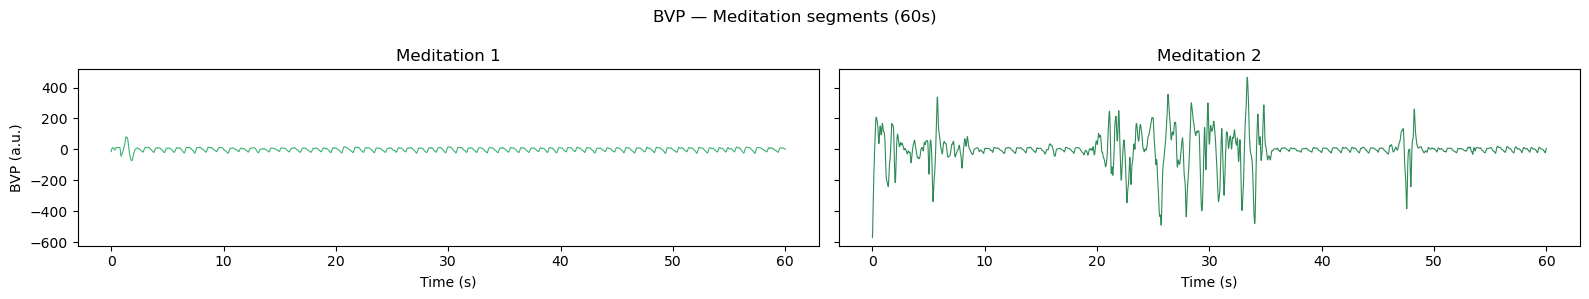

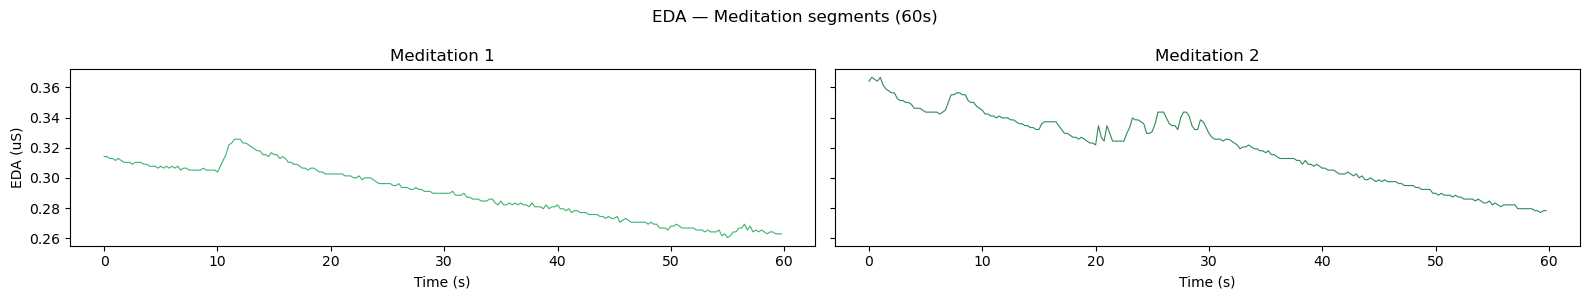

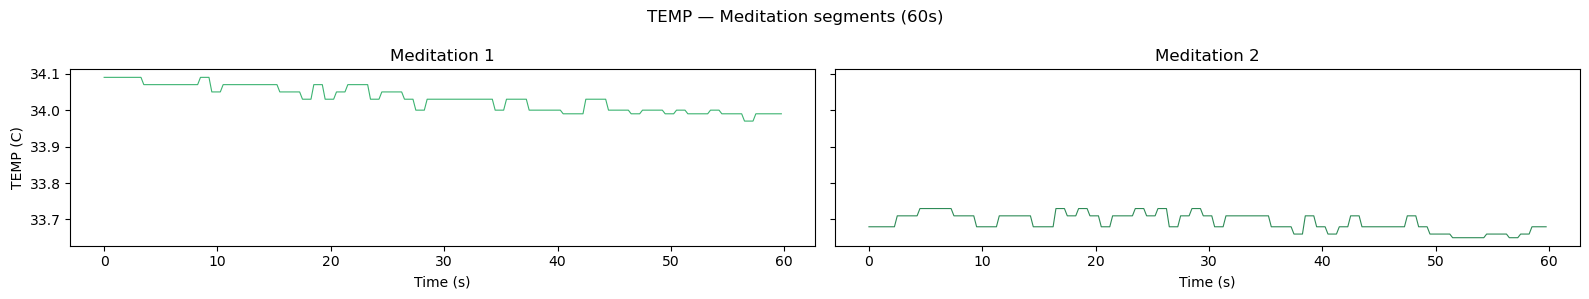

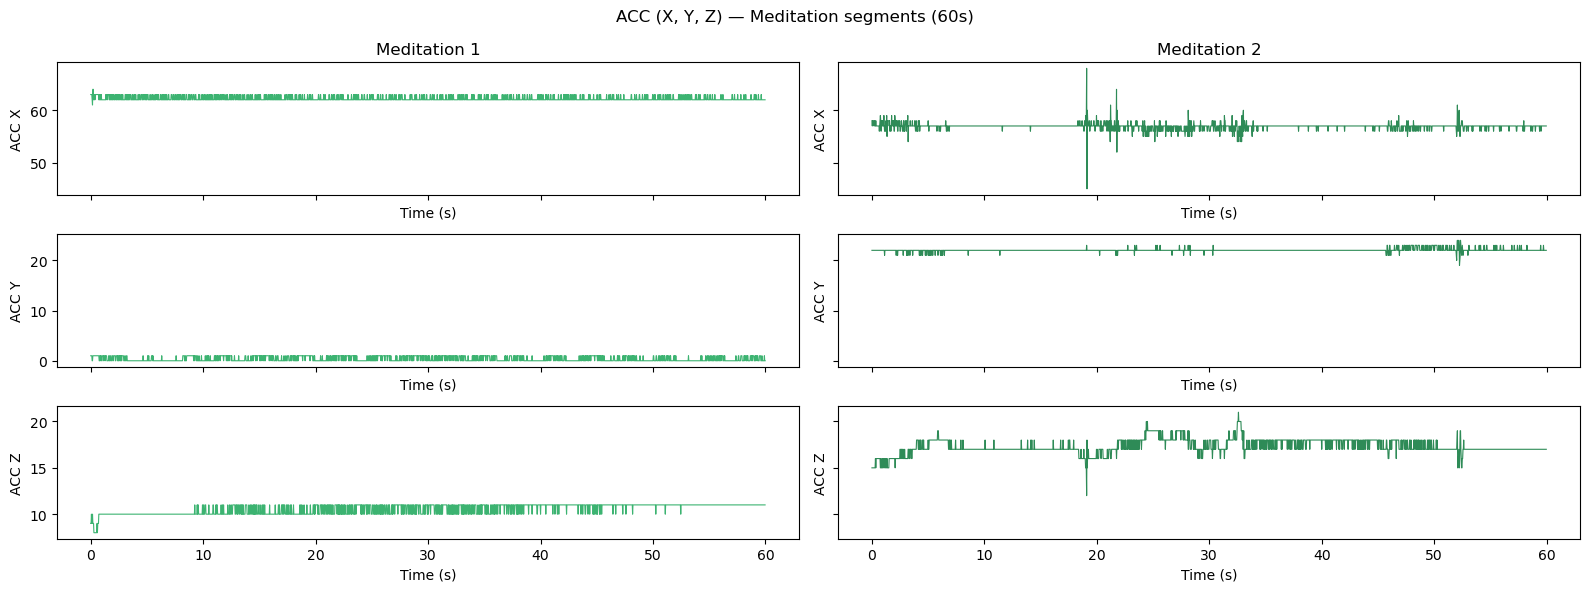

In [8]:
# plotting 60s windows of raw wrist signals for three conditions
print("\nVisualising Raw Signals")
print(f"Preview subject: {data_preview['subject']}")

# Baseline/Stress/Amusement comparison
conditions_plot = {1: "Baseline", 2: "Stress", 3: "Amusement"}
h.plot_raw_wrist_windows(
    data_preview,
    fs_label=FS_LABEL,
    conditions=conditions_plot,
    win_s=60,
    acc_mode="axes",
)

# comparing the start of each Meditation segment
print("\nMeditation segments: start-of-block comparison")
h.plot_meditation_windows(
    data_preview,
    fs_label=FS_LABEL,
    win_s=60,
    acc_mode="axes",
)

The raw signal plots confirm several physiologically expected patterns
across conditions:

**BVP:** The cardiac waveform is clearly visible in all three conditions.
Baseline shows moderate variability with some motion artifacts. Stress
shows the largest amplitude spikes — likely caused by movement during
the public speaking task of the TSST. Amusement shows the cleanest,
most regular pulse pattern, consistent with a seated, relaxed watching
condition.

**EDA:** Interestingly for this subject, baseline shows the highest EDA
(~1.5 μS) with a decreasing trend, while stress (~0.8 μS) and amusement
(~0.3 μS) are lower. This is subject-specific — EDA responses vary
enormously between individuals as observed in our initial exploration,
and a single 60-second window at the start of each condition may not
be representative of the full condition.

**TEMP:** Skin temperature is extremely stable within each 60-second
window as expected. Baseline is the warmest (~35.7°C), amusement is
intermediate (~34.4°C), and stress is the coolest (~34.1°C), possibly
reflecting peripheral vasoconstriction during stress.

**ACC:** Baseline shows substantial movement across all three axes,
suggesting the subject was physically active at that point in the
recording. Stress is relatively still — consistent with standing in
front of a panel during the speech task. Amusement is the most
stationary condition.

**Meditation segments:** The two meditation periods show clearly
different physiological states depending on which condition preceded
them. Meditation 1 (following amusement for Version B subjects like S2)
shows a very clean, low-amplitude BVP, low and steadily decreasing EDA,
and almost no movement — a genuinely relaxed state. Meditation 2
(following stress) shows a much noisier BVP with large amplitude spikes
at the start, higher EDA that gradually decreases, and more movement,
reflecting the physiological carry-over from the stressful TSST. This
difference between the two meditation periods supports treating
meditation as a distinct class with its own physiological signature
rather than collapsing it with baseline.

## Section 2: Signal Preprocessing

Before segmenting the signals into windows and extracting features, we
apply signal-specific preprocessing to each wrist modality. The goal is
to remove noise and artifacts while preserving the physiologically
relevant information needed for feature extraction.


All steps are first demonstrated on subject S2 before being applied
to all subjects in the segmentation loop in Section 3.

### 2.1 Extract Raw Signals

We first extract the raw wrist signals for subject S2 and define the
sampling frequencies confirmed empirically in Section 1.2. These
frequency constants are used throughout the preprocessing and
segmentation steps.

In [9]:
# sampling rates from WESAD (Empatica E4)
FS_BVP = 64
FS_EDA = 4
FS_TEMP = 4
FS_ACC = 32

# extract raw wrist signals for Subject S2
bvp_raw = np.asarray(data_preview["signal"]["wrist"]["BVP"]).flatten()
eda_raw = np.asarray(data_preview["signal"]["wrist"]["EDA"]).flatten()
temp_raw = np.asarray(data_preview["signal"]["wrist"]["TEMP"]).flatten()
acc_raw = np.asarray(data_preview["signal"]["wrist"]["ACC"])

print(f"Raw shapes -> BVP:{bvp_raw.shape}, EDA:{eda_raw.shape}, TEMP:{temp_raw.shape}, ACC:{acc_raw.shape}")

Raw shapes -> BVP:(389056,), EDA:(24316,), TEMP:(24316,), ACC:(194528, 3)


### 2.2 BVP Preprocessing — Bandpass Filter 0.5–8 Hz

BVP (Blood Volume Pulse) is a photoplethysmography (PPG) signal recorded
at 64 Hz. The raw signal contains two main sources of noise that need
to be removed before feature extraction:

- **Baseline wander** (< 0.5 Hz): slow drift caused by respiration and
  movement of the sensor on the skin. This is removed by the high-pass
  component of the bandpass filter.
- **High-frequency noise** (> 8 Hz): electrical interference and
  high-frequency motion artifacts. This is removed by the low-pass
  component.

The cardiac component of the BVP signal — the pulse waveform used for
heart rate and HRV extraction — lies between approximately 0.5 and 4 Hz
for typical resting heart rates (30–240 BPM). We set the upper cutoff
at 8 Hz to provide margin for elevated heart rates during stress while
still removing high-frequency noise. This is consistent with standard
PPG preprocessing practice and the approach used in Schmidt et al.
(2018), Section 4.1. We apply a 4th order Butterworth filter using
zero-phase filtering (filtfilt) to avoid phase distortion.

BVP band-pass: 0.5-8.0 Hz
BVP: var_raw=5756.4445, var_filt=5091.5001, snr_proxy=12.02 dB


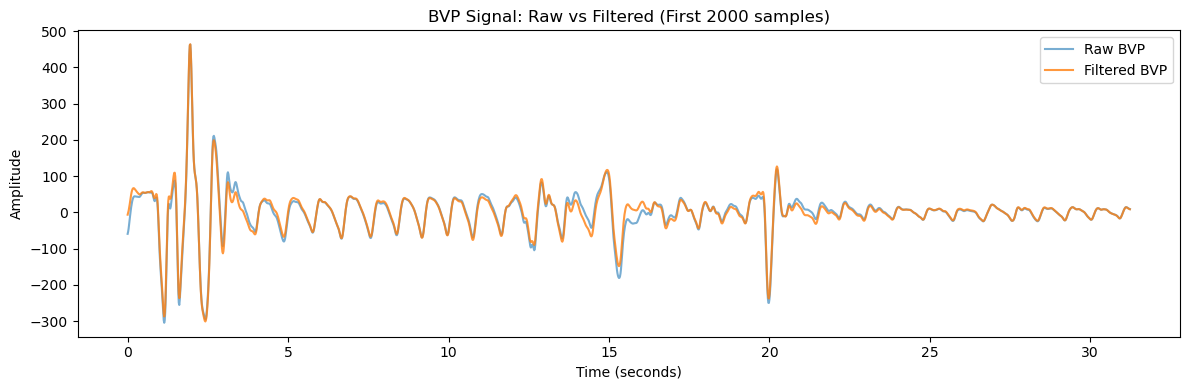

In [ ]:
# BVP: band-pass 0.5–8 Hz (removes baseline wander + high-frequency noise)
bvp_low, bvp_high = 0.5, 8.0
bvp_filt = h.butter_bandpass_filter(bvp_raw, FS_BVP, bvp_low, bvp_high, order=4)
print(f"BVP band-pass: {bvp_low}-{bvp_high} Hz")

def print_stats(name, raw, filt):
    snr_db = h.snr_proxy_db(raw, filt)
    print(f"{name}: var_raw={np.var(raw):.4f}, var_filt={np.var(filt):.4f}, snr_proxy={snr_db:.2f} dB")

print_stats("BVP", bvp_raw, bvp_filt)

# visualise raw vs filtered BVP for a short segment
plt.figure(figsize=(12, 4))
time_axis_bvp = np.arange(len(bvp_raw)) / FS_BVP
plt.plot(time_axis_bvp[:2000], bvp_raw[:2000], label="Raw BVP", alpha=0.6)
plt.plot(time_axis_bvp[:2000], bvp_filt[:2000], label="Filtered BVP", alpha=0.8)
plt.title("BVP Signal: Raw vs Filtered (First 2000 samples)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

The bandpass filter preserves the periodic cardiac waveform while
attenuating out-of-band noise, confirmed by the variance reduction
from 5756 to 5092 and SNR proxy of 12.02 dB. Note that large motion
artifact spikes (visible around 1–3 seconds) are not fully removed
since they fall within the 0.5–8 Hz passband — true artifact removal
would require additional steps such as amplitude thresholding, noted
as a limitation of this pipeline.

### 2.3 EDA Preprocessing — Lowpass Filter 1 Hz

EDA (Electrodermal Activity) reflects sympathetic nervous system
activation and consists of two components — a slow tonic baseline
(skin conductance level, SCL) representing overall arousal level,
and faster phasic responses to stimuli (skin conductance responses,
SCR) that indicate momentary sympathetic activation. Both components
are crucial for affect recognition and occur well below 1 Hz.

Schmidt et al. (2018), Section 4.1 applies a 5 Hz lowpass filter to
the raw EDA signal. However wrist EDA is sampled at only 4 Hz, making
the Nyquist frequency 2 Hz — a 5 Hz cutoff therefore has no practical
effect at this sampling rate. We instead apply a 1 Hz 4th order
Butterworth lowpass filter using zero-phase filtering to avoid phase
distortion, which smooths out any sample-to-sample sensor jitter while
fully preserving both the tonic SCL baseline and the phasic SCR
responses. This is a documented deviation from the paper, adapted for
the wrist sampling rate.

EDA low-pass cutoff used: 1.00 Hz (wrist-adapted)
EDA: var_raw=0.1084, var_filt=0.1083, snr_proxy=33.93 dB


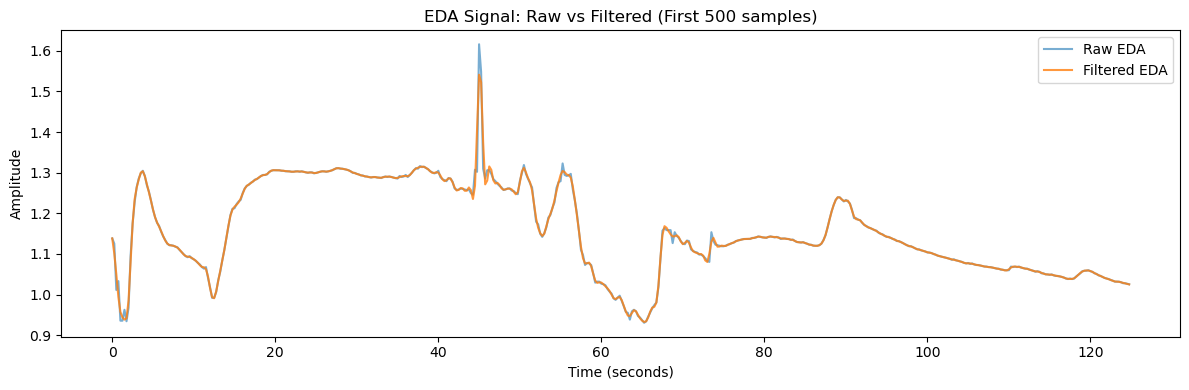

In [11]:
# EDA: low-pass Butterworth
# paper uses 5 Hz, but wrist EDA is 4 Hz so we use 1 Hz to actually smooth while keeping SCR.
eda_cutoff = 1.0
eda_filt = h.butter_lowpass_filter(eda_raw, FS_EDA, eda_cutoff, order=4)
print(f"EDA low-pass cutoff used: {eda_cutoff:.2f} Hz (wrist-adapted)")
print_stats("EDA", eda_raw, eda_filt)

# visualise raw vs filtered EDA for a short segment
plt.figure(figsize=(12, 4))
time_axis_eda = np.arange(len(eda_raw)) / FS_EDA
plt.plot(time_axis_eda[:500], eda_raw[:500], label="Raw EDA", alpha=0.6)
plt.plot(time_axis_eda[:500], eda_filt[:500], label="Filtered EDA", alpha=0.8)
plt.title("EDA Signal: Raw vs Filtered (First 500 samples)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

As expected for a 4 Hz signal, the raw and filtered EDA are nearly
identical — the raw and filtered lines are almost completely overlapping
in the plot. The minimal variance change (0.1084 → 0.1083) and high
SNR proxy of 33.93 dB confirm that the raw EDA signal at 4 Hz contains
almost no out-of-band noise to remove. The filter's main role here is
to ensure consistency in the processing pipeline rather than meaningful
noise reduction. The slow tonic baseline and phasic SCR peaks (visible
around 45–60 seconds) are fully preserved.

### 2.4 TEMP Preprocessing — 5-Second Moving Average

Skin temperature (TEMP) is a very slow-varying physiological signal
sampled at 4 Hz. The paper (Schmidt et al., 2018, Section 4.1, Table 1)
computes features directly on the raw TEMP signal without applying any
filter. We apply a 5-second moving average to reduce minor
sample-to-sample sensor jitter inherent to the Empatica E4 temperature
sensor, while fully preserving the slow physiological dynamics that
carry meaningful information about affective state.

This is a minor documented deviation from the paper. The visualization
starts from the beginning of the baseline condition rather than the
start of the recording to avoid the sensor warm-up period and moving
average edge artifacts at the beginning of the signal.

TEMP moving average window: 5s (20 samples)
TEMP: var_raw=1.0927, var_filt=1.1693, snr_proxy=11.14 dB


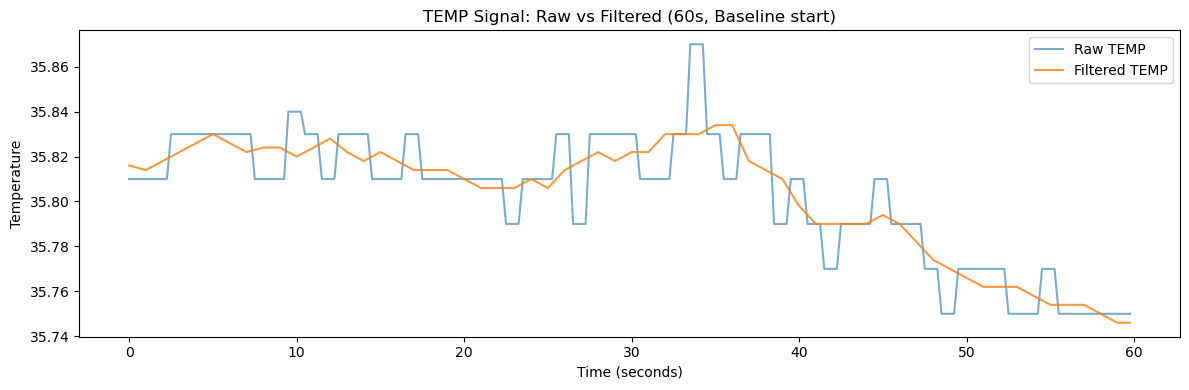

In [12]:
# TEMP: skin temperature is slow and stable at 4 Hz
# we apply a simple moving average to reduce tiny sensor jitter (no windowing/segmentation yet).
temp_win_s = 5  # seconds
temp_win = int(temp_win_s * FS_TEMP)
temp_filt = h.moving_average(temp_raw, temp_win)
print(f"TEMP moving average window: {temp_win_s}s ({temp_win} samples)")
print_stats("TEMP", temp_raw, temp_filt)

# visualise a clean 60s segment to avoid sensor warm-up and edge effects
win_s = 60
idx_label = np.where(labels == 1)[0][0]  # baseline start in label timeline
start_temp = int(idx_label / FS_LABEL * FS_TEMP)
start_temp = max(start_temp, temp_win)  # avoid moving-average edge artifacts
end_temp = start_temp + win_s * FS_TEMP
end_temp = min(end_temp, len(temp_raw))
t_temp = np.arange(end_temp - start_temp) / FS_TEMP

plt.figure(figsize=(12, 4))
plt.plot(t_temp, temp_raw[start_temp:end_temp], label="Raw TEMP", alpha=0.6)
plt.plot(t_temp, temp_filt[start_temp:end_temp], label="Filtered TEMP", alpha=0.8)
plt.title("TEMP Signal: Raw vs Filtered (60s, Baseline start)")
plt.xlabel("Time (seconds)")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()

The moving average effectively smooths the stepped quantization pattern
characteristic of the Empatica E4 temperature sensor — the raw signal
shows discrete jumps between fixed quantization levels while the filtered
signal produces a smooth, continuous trace that better represents the
true underlying skin temperature trend. The 5-second window is short
enough to preserve meaningful slow physiological changes (the gradual
temperature decrease visible from ~35.83°C to ~35.75°C over the 60-second
window) while removing the sensor quantization artifacts. The slight
variance increase from 1.09 to 1.17 reflects the smoothing of sharp
quantization steps into a more continuous signal rather than actual
noise amplification.

### 2.5 ACC Preprocessing — Magnitude Computation

The accelerometer (ACC) records 3-axis acceleration at 32 Hz. Unlike
the other signals, we do not apply a filter to ACC. Instead we compute
the 3D magnitude from the three raw axes:

|g| = √(x² + y² + z²)

This is consistent with Schmidt et al. (2018), Section 4.1, which
computes statistical features both per axis and on the 3D magnitude.
The magnitude provides a single summary of overall movement intensity
that is invariant to device orientation on the wrist, making it more
robust across subjects who may wear the device at slightly different
angles. We keep both the raw axes and the computed magnitude for
feature extraction — per-axis features capture directional movement
patterns while the magnitude captures overall activity level.

ACC axis shapes -> X:(194528,), Y:(194528,), Z:(194528,)
ACC magnitude shape: (194528,)
ACC axis mean/std: X=39.701/19.521, Y=-0.407/33.207, Z=18.991/25.003
ACC magnitude mean/std: 63.434/4.689


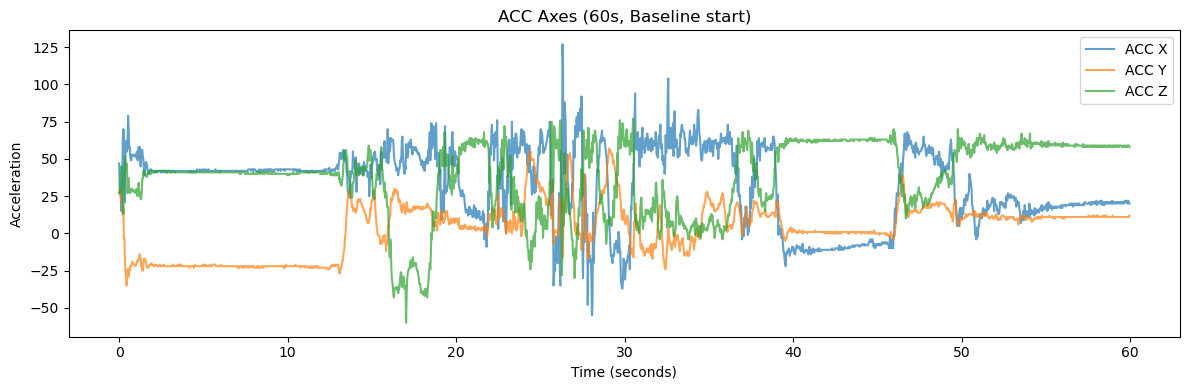

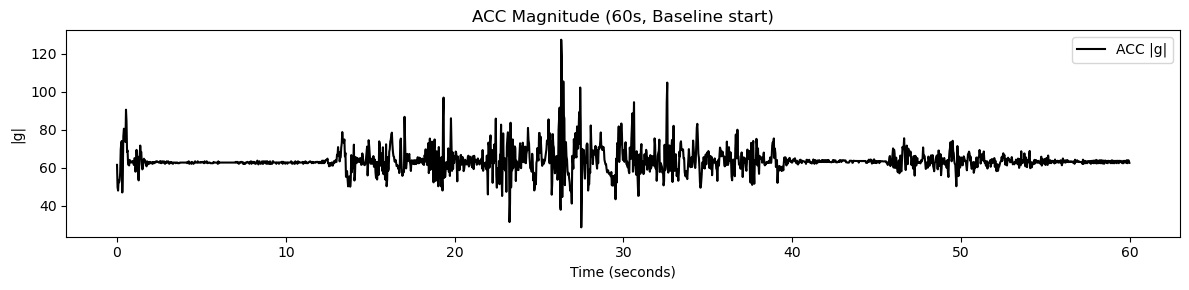

In [13]:
# ACC: 3-axis accelerometer at 32 Hz
acc_x = acc_raw[:, 0]
acc_y = acc_raw[:, 1]
acc_z = acc_raw[:, 2]

# computing magnitude (3D) as in the paper's feature section
acc_mag = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

print(f"ACC axis shapes -> X:{acc_x.shape}, Y:{acc_y.shape}, Z:{acc_z.shape}")
print(f"ACC magnitude shape: {acc_mag.shape}")
print(f"ACC axis mean/std: X={np.mean(acc_x):.3f}/{np.std(acc_x):.3f}, "
      f"Y={np.mean(acc_y):.3f}/{np.std(acc_y):.3f}, "
      f"Z={np.mean(acc_z):.3f}/{np.std(acc_z):.3f}")
print(f"ACC magnitude mean/std: {np.mean(acc_mag):.3f}/{np.std(acc_mag):.3f}")

# visualise a clean 60s segment (Baseline start)
win_s = 60
idx_label = np.where(labels == 1)[0][0]  # baseline start in label timeline
start_acc = int(idx_label / FS_LABEL * FS_ACC)
end_acc = start_acc + win_s * FS_ACC
end_acc = min(end_acc, len(acc_mag))
t_acc = np.arange(end_acc - start_acc) / FS_ACC

plt.figure(figsize=(12, 4))
plt.plot(t_acc, acc_x[start_acc:end_acc], label="ACC X", alpha=0.7)
plt.plot(t_acc, acc_y[start_acc:end_acc], label="ACC Y", alpha=0.7)
plt.plot(t_acc, acc_z[start_acc:end_acc], label="ACC Z", alpha=0.7)
plt.title("ACC Axes (60s, Baseline start)")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(t_acc, acc_mag[start_acc:end_acc], label="ACC |g|", color="black")
plt.title("ACC Magnitude (60s, Baseline start)")
plt.xlabel("Time (seconds)")
plt.ylabel("|g|")
plt.legend()
plt.tight_layout()
plt.show()

The ACC plots reveal significant subject movement during the baseline
condition, particularly between 15–35 seconds where all three axes show
large simultaneous deflections — likely corresponding to the subject
changing posture or position. The stepped pattern visible in the first
~13 seconds across all axes reflects a period of stillness where the
device is stationary and gravity dominates each axis.

The magnitude plot consolidates the three axes into a single activity
measure centered around ~63 |g|, which represents the gravitational
component. The mean magnitude of 63.43 with a low std of 4.69 confirms
that most of this 60-second window is relatively still, with the burst
of activity around 15–35 seconds visible as spikes above the baseline.

The large differences in mean values across axes (X: 39.7, Y: -0.4,
Z: 19.0) reflect the orientation of the device on the wrist relative
to gravity — this is why the magnitude, which is orientation-invariant,
is more useful as a summary feature than any individual axis alone.

## Section 3: Sliding Window Segmentation

We segment the preprocessed wrist signals into fixed-length windows
following Schmidt et al. (2018), Section 4.1, which specifies:
- **Window size:** 60 seconds
- **Window step:** 0.25 seconds (75% overlap between consecutive windows)
- **Label assignment:** majority vote over the label array within each window

The 60-second window size was chosen in the paper following Kreibig et al.
(2010) to capture sufficient physiological dynamics for HRV and EDA
feature extraction. The 0.25-second step produces a large number of
overlapping windows, which increases the dataset size and ensures
temporal coverage of condition transitions.

**Label assignment by majority vote** means that each window is assigned
the label that appears most frequently in the corresponding segment of
the label array (at 700 Hz). Windows where the majority label is not one
of our four conditions of interest (1, 2, 3, 4) are discarded — this
naturally handles transition windows that span two conditions.

The segmentation loop applies to all 15 subjects and performs the
following steps for each subject:
1. Load raw signals and apply preprocessing (same settings as Section 2)
2. Align signals by shortest duration to handle minor length differences
3. Slide the window across the label array in steps of 0.25 seconds
4. For each window: assign majority label, map to each signal's indices,
   extract the corresponding signal segment
5. Store filtered BVP, EDA, TEMP, raw ACC axes, and smoothed ACC
   magnitude for each accepted window

Note that the ACC magnitude is smoothed with a 1-second moving average
inside the segmentation loop to reduce high-frequency jitter before
feature extraction. This is an additional processing step not explicitly
described in the paper and is documented as a minor deviation.

In [14]:
# sliding Window Segmentation (wrist only) - using filtered signals
print("\nSliding Window Segmentation (filtered signals)")

# window settings (paper)
WIN_S = 60.0
STEP_S = 0.25
FS_LABEL = 700  # label sampling rate
fs_wrist = {"BVP": 64, "EDA": 4, "TEMP": 4, "ACC": 32}

# converting window sizes to samples per signal
win_label = int(WIN_S * FS_LABEL)
step_label = int(STEP_S * FS_LABEL)
win_samples = {k: int(WIN_S * v) for k, v in fs_wrist.items()}
print("Window (samples):", win_samples, f"Label window={win_label}, step={step_label}")

KEEP_LABELS = {1: "Baseline", 2: "Stress", 3: "Amusement", 4: "Meditation"}

def majority_label(label_window):
    counts = np.bincount(label_window.astype(int), minlength=8)
    return int(np.argmax(counts)), counts

segments_by_subject = {}
class_counts = {k: 0 for k in KEEP_LABELS}
total_windows = 0
subject_rows = []

for subject_id in subjects:
    data = h.load_subject_pickle(DATA_ROOT, subject_id, verbose=False)
    labels = np.asarray(data["label"]).astype(int)

    # preprocess wrist signals, ensuring we use filtered versions
    bvp = np.asarray(data["signal"]["wrist"]["BVP"]).flatten()
    eda = np.asarray(data["signal"]["wrist"]["EDA"]).flatten()
    temp = np.asarray(data["signal"]["wrist"]["TEMP"]).flatten()
    acc = np.asarray(data["signal"]["wrist"]["ACC"])

    # filtered / processed signals
    bvp_filt = h.butter_bandpass_filter(bvp, fs_wrist["BVP"], 0.5, 8.0, order=4)
    eda_filt = h.butter_lowpass_filter(eda, fs_wrist["EDA"], 1.0, order=4)
    temp_filt = h.moving_average(temp, int(5 * fs_wrist["TEMP"]))

    # ACC: keeping raw axes for compatibility, and compute a smoothed magnitude for downstream features
    acc_raw = acc  # axes (x,y,z)
    acc_x = acc_raw[:, 0]
    acc_y = acc_raw[:, 1]
    acc_z = acc_raw[:, 2]
    acc_mag = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)
    # smooth magnitude with 1s moving average to reduce high-frequency jitter
    acc_mag_filt = h.moving_average(acc_mag, int(1 * fs_wrist["ACC"]))

    # align by the shortest duration across signals + labels
    max_time = min(
        len(labels) / FS_LABEL,
        len(bvp_filt) / fs_wrist["BVP"],
        len(eda_filt) / fs_wrist["EDA"],
        len(temp_filt) / fs_wrist["TEMP"],
        len(acc_mag_filt) / fs_wrist["ACC"],
    )
    max_label_samples = int(max_time * FS_LABEL)

    subject_segments = {"BVP": [], "EDA": [], "TEMP": [], "ACC": [], "ACC_MAG": [], "label": []}
    subject_counts = {k: 0 for k in KEEP_LABELS}
    subject_total = 0

    for start_label in range(0, max_label_samples - win_label + 1, step_label):
        label_window = labels[start_label : start_label + win_label]
        majority, _ = majority_label(label_window)
        if majority not in KEEP_LABELS:
            continue

        # map label index to each sensor index
        start_bvp = int(start_label / FS_LABEL * fs_wrist["BVP"])
        start_eda = int(start_label / FS_LABEL * fs_wrist["EDA"])
        start_temp = int(start_label / FS_LABEL * fs_wrist["TEMP"])
        start_acc = int(start_label / FS_LABEL * fs_wrist["ACC"])

        end_bvp = start_bvp + win_samples["BVP"]
        end_eda = start_eda + win_samples["EDA"]
        end_temp = start_temp + win_samples["TEMP"]
        end_acc = start_acc + win_samples["ACC"]

        if (
            end_bvp > len(bvp_filt)
            or end_eda > len(eda_filt)
            or end_temp > len(temp_filt)
            or end_acc > len(acc_mag_filt)
        ):
            continue

        # storing filtered/processed windows (use filtered signals for downstream steps)
        subject_segments["BVP"].append(bvp_filt[start_bvp:end_bvp])
        subject_segments["EDA"].append(eda_filt[start_eda:end_eda])
        subject_segments["TEMP"].append(temp_filt[start_temp:end_temp])
        # keeping axes for compatibility
        subject_segments["ACC"].append(acc_raw[start_acc:end_acc, :])
        # adding filtered magnitude for models/features
        subject_segments["ACC_MAG"].append(acc_mag_filt[start_acc:end_acc])
        subject_segments["label"].append(majority)

        subject_counts[majority] += 1
        class_counts[majority] += 1
        subject_total += 1
        total_windows += 1

    segments_by_subject[subject_id] = subject_segments
    subject_rows.append({
        "subject": subject_id,
        "total_windows": subject_total,
        "Baseline": subject_counts[1],
        "Stress": subject_counts[2],
        "Amusement": subject_counts[3],
        "Meditation": subject_counts[4],
    })

print(f"\nTotal windows kept: {total_windows}")
print("Class counts (overall):", {KEEP_LABELS[k]: v for k, v in class_counts.items()})

df_counts = pd.DataFrame(subject_rows)
df_counts = df_counts.sort_values("subject", key=lambda s: s.str[1:].astype(int))
display(df_counts)


Sliding Window Segmentation (filtered signals)
Window (samples): {'BVP': 3840, 'EDA': 240, 'TEMP': 240, 'ACC': 1920} Label window=42000, step=175


/Users/louiedaans/Desktop/healthcare-project/helpers.py:28: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")



Total windows kept: 179817
Class counts (overall): {'Baseline': 70429, 'Stress': 39864, 'Amusement': 22300, 'Meditation': 47224}


,subject,total_windows,Baseline,Stress,Amusement,Meditation
7,S2,11556,4576,2460,1448,3072
8,S3,11740,4560,2560,1500,3120
9,S4,11880,4632,2540,1488,3220
10,S5,12044,4792,2580,1496,3176
11,S6,11956,4720,2600,1488,3148
12,S7,11952,4744,2560,1488,3160
13,S8,12020,4676,2680,1480,3184
14,S9,11960,4720,2580,1488,3172
0,S10,12292,4720,2900,1488,3184
1,S11,12076,4720,2720,1472,3164


The segmentation produced 179,817 windows across all 15 subjects with
window counts highly consistent per subject (~12,000 each). Window sizes
in samples confirm the expected dimensions — BVP: 3840, EDA: 240, TEMP:
240, ACC: 1920. The class distribution mirrors the protocol structure:
baseline 39.2%, meditation 26.3%, stress 22.2%, amusement 12.4% —
consistent with Section 1.4 and further confirming that macro F1-score
is the appropriate evaluation metric.

### 3.1 Segmentation Verification

We verify the output of the segmentation loop by inspecting the shape
and content of the stored windows for one example subject, confirming
that all signal dimensions match expectations before proceeding to
feature extraction.

In [15]:
example_subject = subjects[0]
first_idx = 0

print(f"--- Data Format Inspection: {example_subject} ---")

# summary of lengths and types
print(f"Total Segments: {len(segments_by_subject[example_subject]['label'])}")

# inspecting individual sensor arrays within one window
# we print shapes to verify the 60s windows are correct per frequency
wrist_data = segments_by_subject[example_subject]

print("\nShapes for one 60s window:")
print(f"  BVP:  {wrist_data['BVP'][first_idx].shape}  (Expected: 3840 for 64Hz)")
print(f"  ACC:  {wrist_data['ACC'][first_idx].shape}  (Expected: 1920, 3 for 32Hz)")
print(f"  EDA:  {wrist_data['EDA'][first_idx].shape}   (Expected: 240 for 4Hz)")
print(f"  TEMP: {wrist_data['TEMP'][first_idx].shape}   (Expected: 240 for 4Hz)")

# clean way to see the raw values without a massive table
# we look at the first 5 values of each signal to check data types
print("\nRaw Value Samples (First 5 samples of the window):")
print(f"  BVP:  {wrist_data['BVP'][first_idx][:5]}")
print(f"  EDA:  {wrist_data['EDA'][first_idx][:5]}")
print(f"  ACC: \n{wrist_data['ACC'][first_idx][:5]}") # Shows X, Y, Z columns

# global label distribution for this subject
unique, counts = np.unique(wrist_data["label"], return_counts=True)
label_dist = dict(zip(unique, counts))
print(f"\nLabel Distribution for {example_subject}:")
for lbl, count in label_dist.items():
    # Mapping: 1: Baseline, 2: Stress, 3: Amusement, 4: Meditation
    name = {1:"Baseline", 2:"Stress", 3:"Amusement", 4:"Meditation"}.get(lbl, "Other")
    print(f"  {name} (Label {lbl}): {count} windows")

--- Data Format Inspection: S10 ---
Total Segments: 12292

Shapes for one 60s window:
  BVP:  (3840,)  (Expected: 3840 for 64Hz)
  ACC:  (1920, 3)  (Expected: 1920, 3 for 32Hz)
  EDA:  (240,)   (Expected: 240 for 4Hz)
  TEMP: (240,)   (Expected: 240 for 4Hz)

Raw Value Samples (First 5 samples of the window):
  BVP:  [-25.46254154 -22.40295298 -18.0165725  -12.89906527  -7.76544674]
  EDA:  [0.35640458 0.35799045 0.35840948 0.357667   0.357066  ]
  ACC: 
[[58.  8. 25.]
 [58.  8. 25.]
 [57.  8. 25.]
 [57.  8. 25.]
 [58.  8. 25.]]

Label Distribution for S10:
  Baseline (Label 1): 4720 windows
  Stress (Label 2): 2900 windows
  Amusement (Label 3): 1488 windows
  Meditation (Label 4): 3184 windows


All window shapes match expectations exactly — BVP: (3840,), EDA: (240,),
TEMP: (240,), ACC: (1920, 3) — confirming the segmentation correctly
handles the different sampling rates. The raw value samples show
physiologically plausible values: BVP is centered around zero as expected
for a bandpass-filtered AC-coupled signal, EDA values are in the expected
microsiemens range (~0.35 μS for this subject), and ACC shows the expected
integer-like values with a dominant gravitational component visible across
all three axes. The label distribution for S10 (4720 baseline, 2900
stress, 1488 amusement, 3184 meditation) is consistent with the overall
dataset proportions confirmed in the segmentation summary above.

## Section 4: Feature Extraction

We extract a comprehensive set of features from each 60-second window
for all four signal modalities. Feature extraction follows the feature
set described in Schmidt et al. (2018), Section 4.1 and Table 1, adapted
for wrist-only signals. We use NeuroKit2 for physiological signal
processing, particularly for HRV analysis from BVP and tonic/phasic
decomposition of EDA.

The extracted features per window are:

**BVP / HRV** — Heart rate mean and std, HRV time-domain features
(mean, std, NN50, pNN50, RMSSD) and frequency-domain features (ULF,
LF, HF, UHF band energies and LF/HF ratio). A validity flag
`bvp_hrv_freq_valid` indicates whether signal quality was sufficient
for frequency analysis.

**EDA** — Statistical features (mean, std, min, max, slope, range)
computed on the filtered tonic signal, plus phasic SCR features (number
of peaks, mean amplitude, area under curve) extracted via NeuroKit2's
EDA decomposition. A flag `eda_scr_has_peaks` indicates whether any
phasic peaks were detected in the window.

**TEMP** — Statistical features (mean, std, min, max, range) and slope,
computed on the smoothed temperature signal.

**ACC** — Per-axis statistical features (mean, std), 3D magnitude
features (mean, std), absolute integral per axis (total movement energy),
and peak frequency per axis (dominant motion frequency).

This feature set closely mirrors Table 1 of Schmidt et al. (2018),
with the exception of EMG and RESP features which are chest-only and
therefore excluded. The validity flag columns (`bvp_hrv_freq_valid`,
`eda_scr_has_peaks`) are metadata columns that will be converted to int
and used as additional features or dropped in the modelling notebook
based on inspection of their distributions.

In [16]:
print("\nFeature Extraction (wrist-only)")

import importlib
importlib.reload(h)

fs_wrist = {"BVP": 64, "EDA": 4, "TEMP": 4, "ACC": 32}

# set to a subject id (e.g., "S10") for a quick test, or None for all subjects.
TEST_SUBJECT = None

# --- Feature Extraction Overview ---

# SUBJECT & TARGET INFO:
# subject: Unique identifier for each of the 15 participants
# window_index: Sequential index of the 60s segment (0.25s shift)
# label: Affective state (Baseline, Stress, Amusement, or Meditation) (1-4)

# BVP (BLOOD VOLUME PULSE):
# HR_mean/std: Average and variability of Heart Rate
# HRV_mean/std: Average and variability of Heart Rate Variability (inter-beat intervals)
# HRV_nn50: Number of heart rate intervals differing by more than 50ms 
# HRV_pnn50: Percentage of heart rate intervals differing by more than 50ms 
# HRV_rmssd: Root Mean Square of Successive Differences (short-term HRV) 
# HRV_ulf: Energy in Ultra Low Frequency band (0.01-0.04 Hz) 
# HRV_lf: Energy in Low Frequency band (0.04-0.15 Hz) 
# HRV_hf: Energy in High Frequency band (0.15-0.4 Hz) 
# HRV_uhf: Energy in Ultra High Frequency band (0.4-1.0 Hz) 
# HRV_lf_hf: Ratio of Low Frequency to High Frequency components
# bvp_hrv_freq_valid: Boolean flag indicating if signal quality allowed for frequency analysis

# EDA (ELECTRODERMAL ACTIVITY):
# mean/std: Average and variability of skin conductance
# min/max: Minimum and maximum conductance values
# slope: The rate of change in the conductance signal
# range: Difference between max and min conductance
# scr_peaks: Number of identified Skin Conductance Response (phasic) segments
# scr_mean_amp: Average amplitude of the phasic response peaks
# scr_auc: Area Under the Curve for identified phasic segments
# eda_scr_has_peaks: Boolean flag indicating if any peaks were detected in the window

# TEMP (SKIN TEMPERATURE):
# mean/std: Average and variability of body temperature
# min/max: Minimum and maximum temperature values
# range: Difference between max and min temperature
# slope: The rate of change/trend in temperature

# ACC (ACCELEROMETER - 3 AXES):
# x/y/z_mean/std: Average and variability of motion for each axis separately
# mag_mean/std: Average and variability of the 3D magnitude (resultant force)
# x/y/z_absint: Absolute integral (total movement) for each axis
# x/y/z_peakfreq: The dominant frequency of motion for each axis


if TEST_SUBJECT:
    features_df = h.build_feature_dataframe_for_subject(
        segments_by_subject,
        TEST_SUBJECT,
        fs_wrist=fs_wrist,
        fallback="prev",
        acc_smooth_window_s=1.0,
    )
else:
    features_df = h.build_feature_dataframe(
        segments_by_subject,
        fs_wrist=fs_wrist,
        fallback="prev",
        acc_smooth_window_s=1.0,
        verbose=True,
    )

display(features_df.head())
print("Feature shape:", features_df.shape)


Feature Extraction (wrist-only)
Extracting features for Subject S10...


/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111
/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111


Extracting features for Subject S11...
Extracting features for Subject S13...
Extracting features for Subject S14...


/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111
/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111


Extracting features for Subject S15...
Extracting features for Subject S16...
Extracting features for Subject S17...


...

/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111
/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111
/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111


Extracting features for Subject S9...


/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111
/opt/anaconda3/envs/health/lib/python3.14/site-packages/neurokit2/eda/eda_peaks.py:122: RuntimeWarning: All-NaN slice encountered
  valid_peaks = np.logical_and(info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"]))  # pylint: disable=E1111


,subject,window_index,label,bvp_hr_mean,bvp_hr_std,bvp_hrv_mean,bvp_hrv_std,bvp_hrv_nn50,bvp_hrv_pnn50,bvp_hrv_rmssd,...,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
0,S10,0,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,...,61.879907,3.012126,2384.783203,202.807617,2570.923828,0.125,0.125,0.125,1,1
1,S10,1,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,...,61.877399,3.008428,2377.814453,201.671875,2578.465820,0.125,0.125,0.125,1,1
2,S10,2,1,92.743837,30.566826,723.828125,256.147262,59,0.746835,389.281709,...,61.873905,3.010429,2370.814453,200.614258,2585.978516,0.125,0.125,0.125,1,1
3,S10,3,1,92.652350,30.388575,723.572531,254.571460,59,0.737500,386.844992,...,61.870738,3.011397,2363.833008,199.660156,2593.484375,0.125,0.125,0.125,1,1
4,S10,4,1,92.629447,30.394781,723.765432,254.561813,59,0.737500,386.856825,...,61.868780,3.009604,2356.885742,198.826172,2601.025391,0.125,0.125,0.125,1,1


Feature shape: (179817, 46)


In [17]:
# remove columns length limit
pd.set_option("display.max_columns", None)
display(features_df.head())

,subject,window_index,label,bvp_hr_mean,bvp_hr_std,bvp_hrv_mean,bvp_hrv_std,bvp_hrv_nn50,bvp_hrv_pnn50,bvp_hrv_rmssd,bvp_hrv_ulf,bvp_hrv_lf,bvp_hrv_hf,bvp_hrv_uhf,bvp_hrv_lf_hf,eda_mean,eda_std,eda_min,eda_max,eda_slope,eda_range,eda_scr_peaks,eda_scr_mean_amp,eda_scr_auc,temp_mean,temp_std,temp_min,temp_max,temp_range,temp_slope,acc_x_mean,acc_x_std,acc_y_mean,acc_y_std,acc_z_mean,acc_z_std,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
0,S10,0,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,0.001551,0.005276,0.025225,0.009141,0.209149,0.388696,0.044754,0.34759,0.606228,0.001623,0.258638,7,0.062677,0.415006,33.247683,0.048199,33.176,33.322,0.146,0.002654,39.746387,12.666104,2.475993,3.129106,41.014355,19.997278,61.879907,3.012126,2384.783203,202.807617,2570.923828,0.125,0.125,0.125,1,1
1,S10,1,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,0.001551,0.005276,0.025225,0.009141,0.209149,0.388972,0.044758,0.34759,0.606228,0.001624,0.258638,7,0.062677,0.414869,33.248181,0.048316,33.176,33.322,0.146,0.002663,39.630241,12.626917,2.457064,3.110095,41.140055,19.991351,61.877399,3.008428,2377.814453,201.671875,2578.465820,0.125,0.125,0.125,1,1
2,S10,2,1,92.743837,30.566826,723.828125,256.147262,59,0.746835,389.281709,0.001605,0.005238,0.025854,0.009290,0.202613,0.389237,0.044763,0.34759,0.606228,0.001624,0.258638,7,0.062677,0.414794,33.248677,0.048440,33.176,33.322,0.146,0.002673,39.513574,12.586034,2.439437,3.092266,41.265267,19.984413,61.873905,3.010429,2370.814453,200.614258,2585.978516,0.125,0.125,0.125,1,1
3,S10,3,1,92.652350,30.388575,723.572531,254.571460,59,0.737500,386.844992,0.001604,0.005119,0.025099,0.009718,0.203935,0.389497,0.044764,0.34759,0.606228,0.001625,0.258638,7,0.062677,0.414637,33.249171,0.048570,33.176,33.322,0.146,0.002684,39.397217,12.544515,2.423535,3.075650,41.390365,19.976378,61.870738,3.011397,2363.833008,199.660156,2593.484375,0.125,0.125,0.125,1,1
4,S10,4,1,92.629447,30.394781,723.765432,254.561813,59,0.737500,386.856825,0.001603,0.005119,0.025099,0.009718,0.203940,0.389762,0.044763,0.34759,0.606228,0.001625,0.258638,7,0.062677,0.414685,33.249662,0.048708,33.176,33.322,0.146,0.002695,39.281429,12.502663,2.409635,3.060331,41.516048,19.967527,61.868780,3.009604,2356.885742,198.826172,2601.025391,0.125,0.125,0.125,1,1


The feature matrix contains 44 columns per window: 3 identifier columns
(subject, window_index, label) and 41 features covering all four signal
modalities. The final feature matrix has shape (179,817 × 46) —
consistent with the segmentation output in Section 3, with 46 columns
(3 identifiers + 41 features + 2 flag columns). The first few rows all
belong to subject S10, label 1 (baseline), with consecutive window
indices — confirming the 0.25-second step produces heavily overlapping
windows where features change only gradually between adjacent rows.

Feature values look physiologically plausible: BVP heart rate ~92 BPM
with HRV mean ~730 ms (consistent with resting baseline), EDA ~0.39 μS
(low conductance as expected during baseline), TEMP ~33.25°C, and ACC
magnitude ~62 |g| consistent with the gravitational component observed
in Section 2.5. Both flag columns (eda_scr_has_peaks, bvp_hrv_freq_valid)
are 1 for these windows, indicating valid feature extraction. These
columns will be inspected and handled in the modelling notebook before
training.

### 4.1 Feature Quality Check

Before saving the feature matrix we inspect null values and zero values
per column to identify any feature extraction failures that will need
to be addressed in the modelling notebook.

In [18]:
# check null values % per column
null_percent = features_df.isnull().mean() * 100
print("\nNull values percentage per column:")
print(null_percent[null_percent > 0].sort_values(ascending=False))


Null values percentage per column:
Series([], dtype: float64)


In [19]:
# check 0 values % per column
zero_percent = (features_df == 0).mean() * 100
print("\nZero values percentage per column:")
print(zero_percent[zero_percent > 0].sort_values(ascending=False))


Zero values percentage per column:
eda_scr_mean_amp      16.532920
bvp_hrv_ulf            0.466029
bvp_hrv_lf             0.023357
bvp_hrv_lf_hf          0.023357
window_index           0.008342
bvp_hrv_freq_valid     0.008342
bvp_hrv_hf             0.004449
dtype: float64


In [20]:
# save the features dataframe for later use
features_df.to_csv("wesad_wrist_features.csv", index=False)

No null values were found in the feature matrix — the fallback imputation
strategy in the feature extraction pipeline successfully handled all
windows where NeuroKit2 failed to extract certain features.

The zero value inspection reveals a few columns worth noting:

- **eda_scr_mean_amp (16.5%):** Expected — windows with no detected SCR
  peaks (eda_scr_has_peaks=0) will have zero mean amplitude since there
  are no peaks to average. This is physiologically valid, not a data
  quality issue.
- **bvp_hrv_ulf (0.47%), bvp_hrv_lf (0.02%), bvp_hrv_lf_hf (0.02%),
  bvp_hrv_hf (0.004%):** A small number of windows where HRV frequency
  analysis returned zero — these correspond to windows where
  bvp_hrv_freq_valid=0, indicating insufficient signal quality for
  frequency decomposition.
- **window_index (0.008%) and bvp_hrv_freq_valid (0.008%):** The first
  window of each subject has window_index=0 (expected), and the same
  proportion of windows have invalid HRV frequency features.

These issues will be handled in the modelling notebook by inspecting
the flag columns and applying appropriate imputation or dropping
strategies before training.

The feature matrix is saved to `wesad_wrist_features.csv` and serves
as the input to the modelling notebook.